## Завдання 1
Підготуйте дані для аналізу.
 - Створіть невеликий набір із 5-7 речень (наприклад, відгуки про продукт).
 - Очистіть текст від пунктуації та приведіть до нижнього регістру.
 - Розділіть текст на токени (слова) за допомогою nltk.word_tokenize.
 - Підрахуйте загальну кількість токенів і виведіть перші 10.

In [1]:
feedbacks = """The product quality exceeded my expectations. It feels durable and well-made.
Very easy to use, even for someone who isn’t tech-savvy.
The design is modern and attractive. I received many compliments on it.
Delivery was fast, and the packaging kept the product perfectly safe.
Customer support responded quickly and solved my issue professionally.
The product works exactly as described and offers great value for the price.
I’ve been using it daily for weeks, and it still performs perfectly.
Setup was simple and took only a few minutes.
I appreciate the attention to detail and the premium feel of the product.
Battery life is impressive and lasts much longer than I expected.
The instructions were clear and easy to follow.
This product saved me a lot of time and made my daily tasks easier.
Compared to similar products, this one stands out because of its reliability.
I would definitely recommend this product to friends and family.
Overall, I’m very satisfied with my purchase and would buy from this brand again.
"""

In [2]:
import re
def prepare(phrase: str) -> str:
    return re.sub('\n', ' ', re.sub(r'([^\w\s])+', '', phrase.lower()))

prepared = prepare(feedbacks)
prepared

'the product quality exceeded my expectations it feels durable and wellmade very easy to use even for someone who isnt techsavvy the design is modern and attractive i received many compliments on it delivery was fast and the packaging kept the product perfectly safe customer support responded quickly and solved my issue professionally the product works exactly as described and offers great value for the price ive been using it daily for weeks and it still performs perfectly setup was simple and took only a few minutes i appreciate the attention to detail and the premium feel of the product battery life is impressive and lasts much longer than i expected the instructions were clear and easy to follow this product saved me a lot of time and made my daily tasks easier compared to similar products this one stands out because of its reliability i would definitely recommend this product to friends and family overall im very satisfied with my purchase and would buy from this brand again '

In [3]:
from nltk.tokenize import word_tokenize
import nltk
nltk.download(["punkt_tab", "stopwords", "wordnet"])
words = word_tokenize(prepared)
words

ModuleNotFoundError: No module named 'nltk'

## Завдання 2
Застосуйте лематизацію та стеммінг.
 - Завантажте WordNetLemmatizer і PorterStemmer з бібліотеки NLTK.
 - Перетворіть усі токени на леми і на стеми.
 - Порівняйте перші 10 вихідних слів, їхні леми та стеми в таблиці. Наприклад, так:

|Початкове слово|Лемма|Стем|
|-|-|-|
|example|Example|exampl|
|...|...|...|

In [10]:
words_count = len(words)
print(''.join([word+'\n' for word in words[:10]]))

the
product
quality
exceeded
my
expectations
it
feels
durable
and



In [16]:
from nltk.stem import WordNetLemmatizer, PorterStemmer

lemmatizer = WordNetLemmatizer()
lemma = lemmatizer.lemmatize(words[8])
print(lemma)

stemmer = PorterStemmer()
stem = stemmer.stem(words[8])
print(stem)

durable
durabl


In [26]:
from IPython.display import Markdown as md

table = """ 
|Початкове слово|Лемма|Стем|
|-|-|-|
"""

for word in words[:10]:
    lemma = lemmatizer.lemmatize(word)
    stem = stemmer.stem(word)
    table += f"| {word} | {lemma} | {stem} |\n"

md(table)

 
|Початкове слово|Лемма|Стем|
|-|-|-|
| the | the | the |
| product | product | product |
| quality | quality | qualiti |
| exceeded | exceeded | exceed |
| my | my | my |
| expectations | expectation | expect |
| it | it | it |
| feels | feel | feel |
| durable | durable | durabl |
| and | and | and |


## Завдання 3
Видаліть стоп-слова і проаналізуйте частотність.
 - Завантажте список англійських стоп-слів nltk.corpus.stopwords.words('english').
Видаліть із токенів усі стоп-слова.
 - Підрахуйте частоту слів, що залишилися, за допомогою collections.Counter.
 - Виведіть 10 найчастіших слів та їхню кількість.

In [32]:
from nltk.corpus import stopwords
stop_words = stopwords.words('english')
print(stop_words[:10])
print(stop_words[9::-1])

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']
['an', 'am', 'all', 'ain', 'against', 'again', 'after', 'above', 'about', 'a']


In [33]:
sem_words = [w for w in words if not w in stop_words]
print(f"words: {len(words)}, semantic words: {len(sem_words)}")

words: 169, semantic words: 96


In [41]:
from collections import Counter
freqs = Counter(sem_words)
sorted_list = sorted(list(freqs.items()), key=lambda p: p[1], reverse=True)
sorted(list(freqs.items()), key=lambda p: p[1], reverse=True)

[('product', 6),
 ('easy', 2),
 ('perfectly', 2),
 ('daily', 2),
 ('would', 2),
 ('quality', 1),
 ('exceeded', 1),
 ('expectations', 1),
 ('feels', 1),
 ('durable', 1),
 ('wellmade', 1),
 ('use', 1),
 ('even', 1),
 ('someone', 1),
 ('isnt', 1),
 ('techsavvy', 1),
 ('design', 1),
 ('modern', 1),
 ('attractive', 1),
 ('received', 1),
 ('many', 1),
 ('compliments', 1),
 ('delivery', 1),
 ('fast', 1),
 ('packaging', 1),
 ('kept', 1),
 ('safe', 1),
 ('customer', 1),
 ('support', 1),
 ('responded', 1),
 ('quickly', 1),
 ('solved', 1),
 ('issue', 1),
 ('professionally', 1),
 ('works', 1),
 ('exactly', 1),
 ('described', 1),
 ('offers', 1),
 ('great', 1),
 ('value', 1),
 ('price', 1),
 ('ive', 1),
 ('using', 1),
 ('weeks', 1),
 ('still', 1),
 ('performs', 1),
 ('setup', 1),
 ('simple', 1),
 ('took', 1),
 ('minutes', 1),
 ('appreciate', 1),
 ('attention', 1),
 ('detail', 1),
 ('premium', 1),
 ('feel', 1),
 ('battery', 1),
 ('life', 1),
 ('impressive', 1),
 ('lasts', 1),
 ('much', 1),
 ('longer'

In [45]:
table = """
|Слово|Кількість|
|-|-|
"""

for item in sorted_list:
    if item[1] > 1:
        table += f"| {item[0]} | {item[1]} |\n"
    
md(table)


|Слово|Кількість|
|-|-|
| product | 6 |
| easy | 2 |
| perfectly | 2 |
| daily | 2 |
| would | 2 |


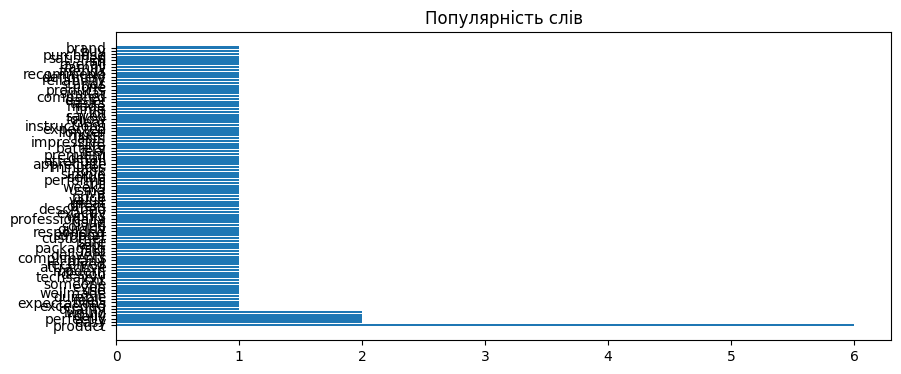

In [49]:
import matplotlib.pyplot as plt
_, ax = plt.subplots(figsize=(10, 4))
names = [item[0] for item in sorted_list]
count = [item[1] for item in sorted_list]
ax.barh(names, count)
ax.set_title("Популярність слів")
plt.show()